In [1]:
filename = "../eos/lhcb/wg/semileptonic/RDsHad/AP/v2/ap_moreinfopid/rds_preprocess_2012_13563002_magdown_rs.root"

In [2]:
import ROOT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Welcome to JupyROOT 6.28/00


In [3]:
rdf = ROOT.RDataFrame("DecayTree", filename)

In [4]:
columns_to_load = [ c for c in rdf.GetColumnNames() if "Xc" in str(c) and any(sub in str(c) for sub in ["ENDVERTEX", "MM", "PX", "PY", "PZ", "PE"]) \
  and not any(sub in str(c) for sub in [ 'DTF', '_0_', '_COV_']) ]
#columns_to_load
df = pd.DataFrame(rdf.Cache(columns_to_load).AsNumpy())

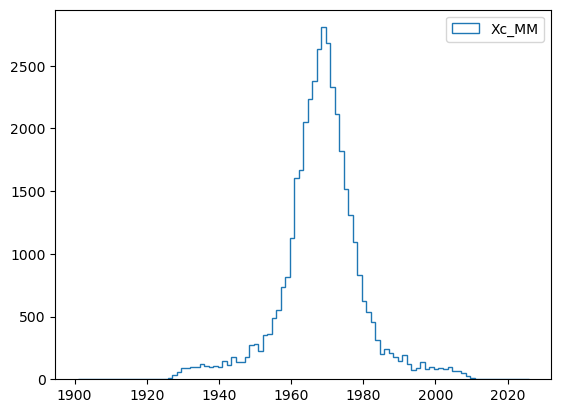

In [5]:
plt.hist(df.Xc_MM, bins=100, histtype='step', label='Xc_MM')
plt.legend();

In [6]:
%%time
def createLV(PX, PY, PZ, PE):
    return ROOT.TLorentzVector(PX, PY, PZ, PE)

df['K1'] = df.apply(lambda x: createLV(x.p1_fromXc_PX, x.p1_fromXc_PY, x.p1_fromXc_PZ, x.p1_fromXc_PE), axis=1)
df['K2'] = df.apply(lambda x: createLV(x.p2_fromXc_PX, x.p2_fromXc_PY, x.p2_fromXc_PZ, x.p2_fromXc_PE), axis=1)
df['pi3'] = df.apply(lambda x: createLV(x.p3_fromXc_PX, x.p3_fromXc_PY, x.p3_fromXc_PZ, x.p3_fromXc_PE), axis=1)
df['K1_K2_M'] = df.apply(lambda x: (x.K1 + x.K2).M(), axis=1)

def compute_energy(px, py, pz, mass):
    p2 = px * px + py * py + pz * pz
    E2 = p2 + mass * mass
    E = np.sqrt(E2)
    return E

df['p2_fromXc_pi2_PE'] = df.apply(lambda x: compute_energy(x.p2_fromXc_PX, x.p2_fromXc_PY, x.p2_fromXc_PZ, 139.57), axis=1)
df['pi2'] = df.apply(lambda x: createLV(x.p2_fromXc_PX, x.p2_fromXc_PY, x.p2_fromXc_PZ, x.p2_fromXc_pi2_PE), axis=1)
df['K1_pi2_pi3_M'] = df.apply(lambda x: (x.K1 + x.pi2 + x.pi3).M(), axis=1)

CPU times: user 7.56 s, sys: 278 ms, total: 7.84 s
Wall time: 7.83 s


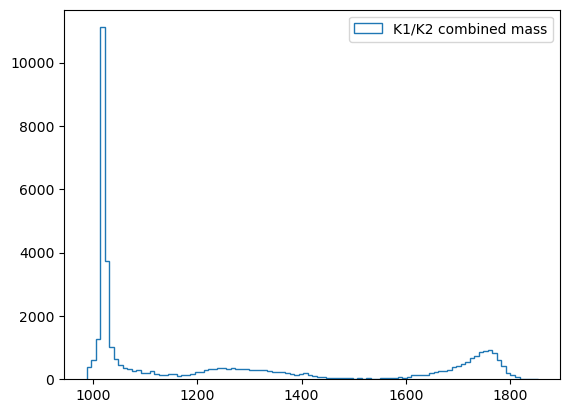

In [7]:
plt.hist(df.K1_K2_M, bins=100, histtype='step', label='K1/K2 combined mass')
plt.legend();

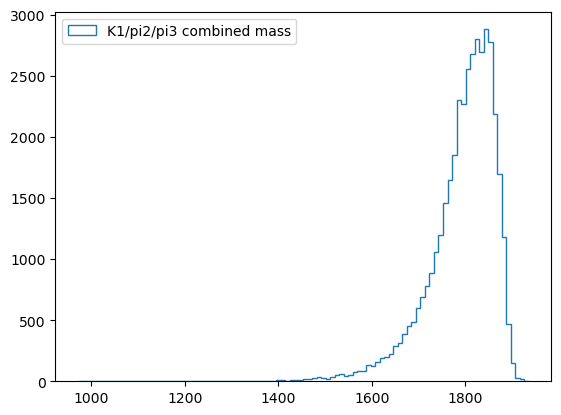

In [8]:
plt.hist(df.K1_pi2_pi3_M, bins=100, histtype='step', label='K1/pi2/pi3 combined mass')
plt.legend();